<div style="background:linear-gradient(135deg,#001F3F 0%,#EE3A43 100%);padding:40px 32px;border-left:6px solid #0093D5;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">03b — Subscriber Clustering · Dataset 2</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · KMeans · PCA · DBSCAN · 4,896 Subscribers · 24 KPI Features</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Input</strong><br/>churn_features.parquet (Dataset 2)</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Methods</strong><br/>KMeans · PCA · DBSCAN · Silhouette · DBI</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Output</strong><br/>models/clustering/kmeans_users.parquet · pca.pkl · dbscan_users.parquet</div>
</div></div>

---
## What this notebook does

**Unsupervised subscriber clustering** on Dataset 2 (4,896 subscribers, 24 KPI features).

| Method | Purpose | Output |
|--------|---------|--------|
| **PCA** | Reduce 24 KPI features → 2D for visualisation | `pca_x`, `pca_y` per subscriber |
| **Elbow + Silhouette** | Find optimal number of clusters k | Best k selection |
| **KMeans** | Assign each subscriber to a cluster | `kmeans_cluster` label |
| **DBSCAN** | Detect outlier subscribers (noise) | `dbscan_cluster` (-1 = outlier) |

### Why cluster subscribers?
```
Different subscriber profiles have different 5G behaviour:
  Cluster 0 — High 5G adopters:  high ratio_5g, high traffic_5g
  Cluster 1 — Low activity:      low session_active_rate, low duration
  Cluster 2 — Voice-heavy:       high voip_quality issues, high client_rtt
  ...

Each cluster = a natural NOC target group for different interventions.
```

In [1]:
import pandas as pd
import numpy  as np
import warnings, joblib
from pathlib import Path

from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.cluster          import KMeans, DBSCAN
from sklearn.metrics          import silhouette_score, davies_bouldin_score

import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR  = Path('data')
PROC_DIR  = Path('data/processed')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
CLUST_DIR = MODEL_DIR / 'clustering'
FIG_DIR   = OUT_DIR   / 'figures'
for d in [CLUST_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280', cyan='#22D3EE')
PALETTE = [HW['red'], HW['blue'], HW['amber'], HW['green'],
           HW['purple'], HW['cyan'], '#F97316', '#EC4899']

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'#E5E7EB',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'axes.grid.axis':'y','grid.color':'#F3F4F6','axes.labelcolor':HW['navy'],
    'axes.labelweight':'bold','axes.titlesize':13,'axes.titleweight':'bold',
    'axes.titlecolor':HW['navy'],'xtick.color':HW['muted'],'ytick.color':HW['muted'],
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')
print('✅ Setup complete')

✅ Setup complete


---
## §1 — Load Dataset 2

In [2]:
feat_df = None
for p in [OUT_DIR/'churn_features.parquet', PROC_DIR/'churn_features.parquet']:
    if p.exists():
        feat_df = pd.read_parquet(p)
        feat_df.columns = feat_df.columns.str.lower().str.strip()
        print(f'churn_features: {len(feat_df):,} rows  ← {p}')
        print(f'Columns ({len(feat_df.columns)}): {list(feat_df.columns[:8])}...')
        break
if feat_df is None:
    raise FileNotFoundError('churn_features.parquet not found — run NB04')

# ── Feature columns for clustering ────────────────────────────────────
EXCLUDE = {'msisdn','churn','churn_predicted','churn_actual','risk_level',
           'churn_probability','churn_prob','churn_prob_xgb',
           'c1_low_usage','c2_low_dur'}
FEAT_COLS = [c for c in feat_df.select_dtypes(include=[np.number]).columns
             if c not in EXCLUDE]

print(f'\nClustering features ({len(FEAT_COLS)}): {FEAT_COLS}')

X_raw = feat_df[FEAT_COLS].fillna(feat_df[FEAT_COLS].median())

# ── Province column for region distribution ───────────────────────────
prov_col = next((c for c in feat_df.columns if 'province' in c.lower()), None)
if prov_col:
    # Load province name map
    province_map = {}
    for lep in [MODEL_DIR/'le_province.pkl', MODEL_DIR/'churn_le_province.pkl']:
        if lep.exists():
            le_p = joblib.load(lep)
            province_map = {i: n for i, n in enumerate(le_p.classes_)}
            break
    if not province_map:
        _TN = ['Ariana','Béja','Ben Arous','Bizerte','Gabès','Gafsa',
               'Jendouba','Kairouan','Kasserine','Kébili','Kef','Mahdia',
               'Manouba','Médenine','Monastir','Nabeul','Sfax','Sidi Bouzid',
               'Siliana','Sousse','Tataouine','Tozeur','Tunis','Zaghouan']
        province_map = {i: n for i, n in enumerate(_TN)}
    print(f'Province column: {prov_col} ({feat_df[prov_col].nunique()} values)')
print('\n✅ Data loaded')

churn_features: 4,896 rows  ← data\processed\churn_features.parquet
Columns (26): ['msisdn', 'churn', 'avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g']...

Clustering features (24): ['avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g', 'total_traffic', 'traffic_5g', 'duration', 'nightly_ratio', 'gaming_ratio', 'social_ratio', 'traffic_diversity', 'brand_encoded', 'brand_freq', 'brand_churn_rate', 'generation_numeric', 'is_5g_capable', 'days_since_last_activity', 'activity_recency_score', 'province_encoded', 'province_freq', 'province_churn_rate', 'congestion_level']
Province column: province_encoded (24 values)

✅ Data loaded


---
## §2 — PCA Dimensionality Reduction

Total features    : 24
Components for 90% variance: 17
Components for 95% variance: 20
2D variance       : 20.4%

pca.pkl saved: models\clustering/pca.pkl
  Saved: data\outputs\figures\fig03b_A_pca_variance.png


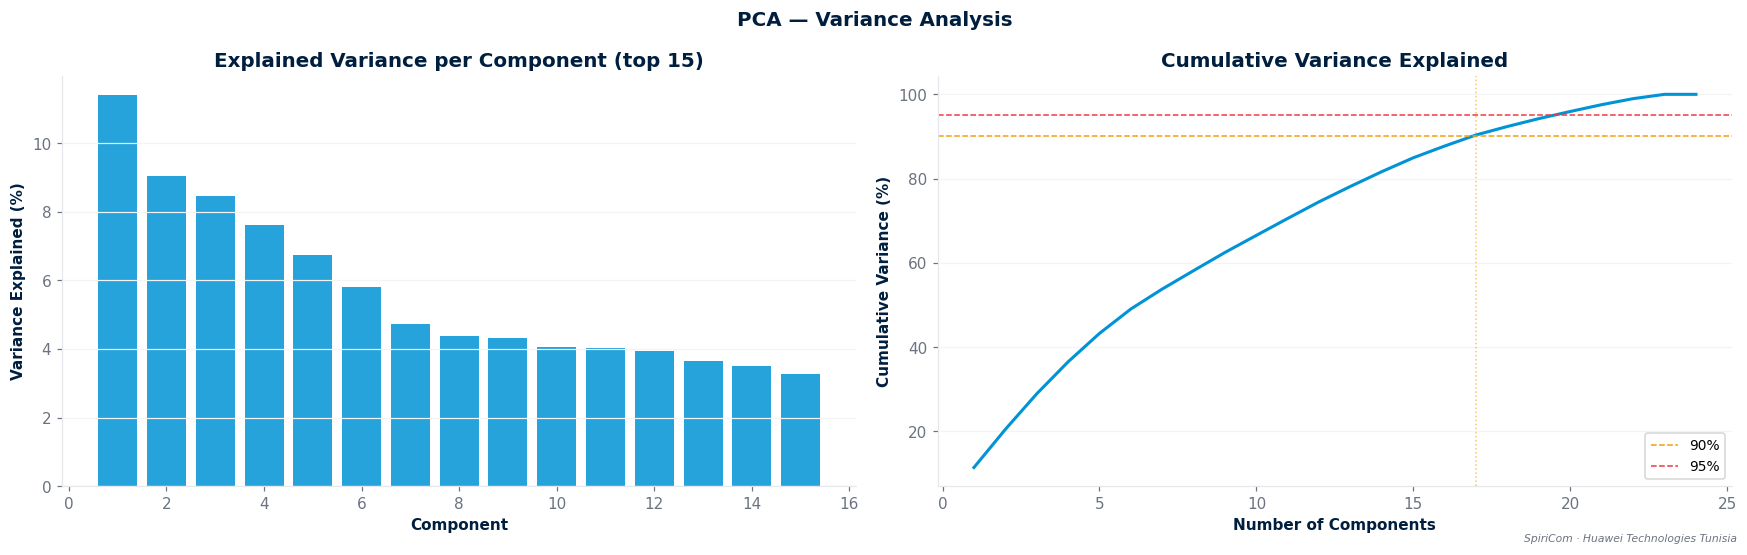

In [3]:
# ── 2.1  Scale + PCA ─────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Full PCA to check variance explained
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90    = int(np.argmax(cum_var >= 0.90)) + 1
n_95    = int(np.argmax(cum_var >= 0.95)) + 1
var_2d  = round(float(pca_full.explained_variance_ratio_[:2].sum() * 100), 1)

print(f'Total features    : {len(FEAT_COLS)}')
print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'2D variance       : {var_2d}%')

# 2D PCA for scatter
pca_2d  = PCA(n_components=2, random_state=42)
X_2d    = pca_2d.fit_transform(X_scaled)

# Save PCA model
joblib.dump(pca_2d, CLUST_DIR / 'pca.pkl')
print(f'\npca.pkl saved: {CLUST_DIR}/pca.pkl')

# Plot variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCA — Variance Analysis', fontsize=13, fontweight='bold', color=HW['navy'])

ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_[:15])+1),
       pca_full.explained_variance_ratio_[:15] * 100,
       color=HW['blue'], alpha=0.85)
ax.set_title('Explained Variance per Component (top 15)')
ax.set_xlabel('Component')
ax.set_ylabel('Variance Explained (%)')

ax = axes[1]
ax.plot(range(1, len(cum_var)+1), cum_var * 100, color=HW['blue'], lw=2)
ax.axhline(90, color=HW['amber'], ls='--', lw=1, label='90%')
ax.axhline(95, color=HW['red'],   ls='--', lw=1, label='95%')
ax.axvline(n_90, color=HW['amber'], ls=':', lw=1, alpha=0.6)
ax.set_title('Cumulative Variance Explained')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance (%)')
ax.legend(fontsize=9)

wm(fig); plt.tight_layout()
save_fig('fig03b_A_pca_variance')
plt.show()

---
## §3 — Optimal K: Elbow + Silhouette

Computing elbow + silhouette (k=2..8)...
  k=2: inertia=109,563  silhouette=0.0767  DBI=3.2351
  k=3: inertia=100,886  silhouette=0.1603  DBI=2.3122
  k=4: inertia=95,472  silhouette=0.1007  DBI=2.4564
  k=5: inertia=90,637  silhouette=0.1084  DBI=2.2420
  k=6: inertia=86,791  silhouette=0.0825  DBI=1.9135
  k=7: inertia=81,918  silhouette=0.1227  DBI=1.8606
  k=8: inertia=78,281  silhouette=0.1273  DBI=1.7269

→ Optimal k = 3  (silhouette=0.1603)
  Saved: data\outputs\figures\fig03b_B_optimal_k.png


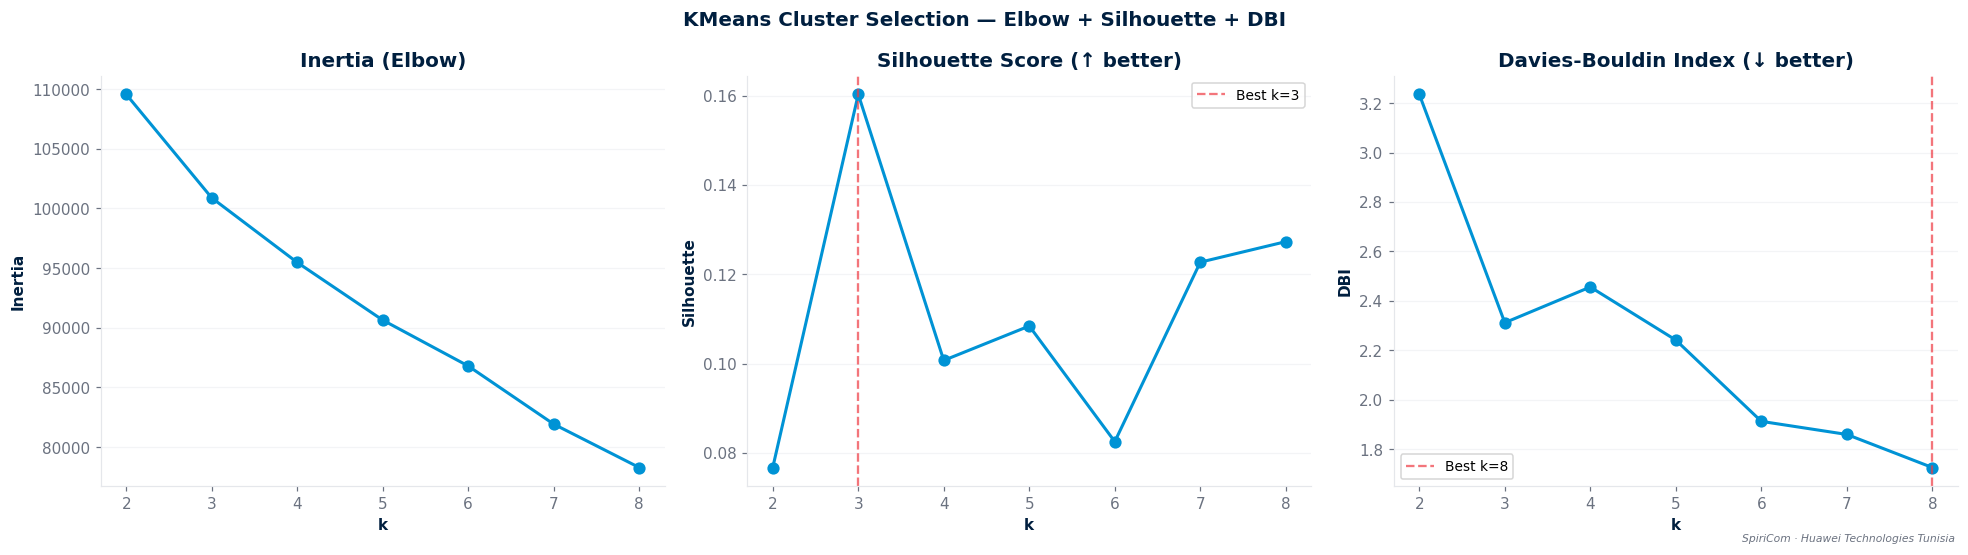

In [4]:
# ── 3.1  Elbow + silhouette for k = 2..8 ─────────────────────────────
print('Computing elbow + silhouette (k=2..8)...')
K_RANGE   = range(2, 9)
inertias  = []
sil_scores = []
dbi_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil  = silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled)), random_state=42)
    dbi  = davies_bouldin_score(X_scaled, labels)
    sil_scores.append(round(sil, 4))
    dbi_scores.append(round(dbi, 4))
    print(f'  k={k}: inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  DBI={dbi:.4f}')

# Best k: highest silhouette
OPTIMAL_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n→ Optimal k = {OPTIMAL_K}  (silhouette={max(sil_scores):.4f})')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('KMeans Cluster Selection — Elbow + Silhouette + DBI',
             fontsize=13, fontweight='bold', color=HW['navy'])

ks = list(K_RANGE)
for ax, vals, title, ylab, best_fn in [
    (axes[0], inertias,   'Inertia (Elbow)',            'Inertia',    None),
    (axes[1], sil_scores, 'Silhouette Score (↑ better)', 'Silhouette', max),
    (axes[2], dbi_scores, 'Davies-Bouldin Index (↓ better)', 'DBI',   min),
]:
    ax.plot(ks, vals, color=HW['blue'], lw=2, marker='o', markersize=7)
    if best_fn:
        bk = ks[vals.index(best_fn(vals))]
        ax.axvline(bk, color=HW['red'], ls='--', lw=1.5, alpha=0.7, label=f'Best k={bk}')
        ax.legend(fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel(ylab)
    ax.set_xticks(ks)

wm(fig); plt.tight_layout()
save_fig('fig03b_B_optimal_k')
plt.show()

---
## §4 — KMeans with Optimal K

Fitting KMeans (k=3)...

Cluster profiles (mean KPI values):
Cluster         N     Pct  Top features...
  Cluster 0    3,586   73.2%  session_active_rate=0.000, traffic_5g=200203.053, ratio_5g=0.002
  Cluster 1    1,066   21.8%  ratio_5g=0.688, gaming_ratio=0.105, session_active_rate=0.000
  Cluster 2      244    5.0%  session_active_rate=1.000, traffic_5g=365236368.623, is_5g_capable=0.996
  Saved: data\outputs\figures\fig03b_C_pca_scatter.png


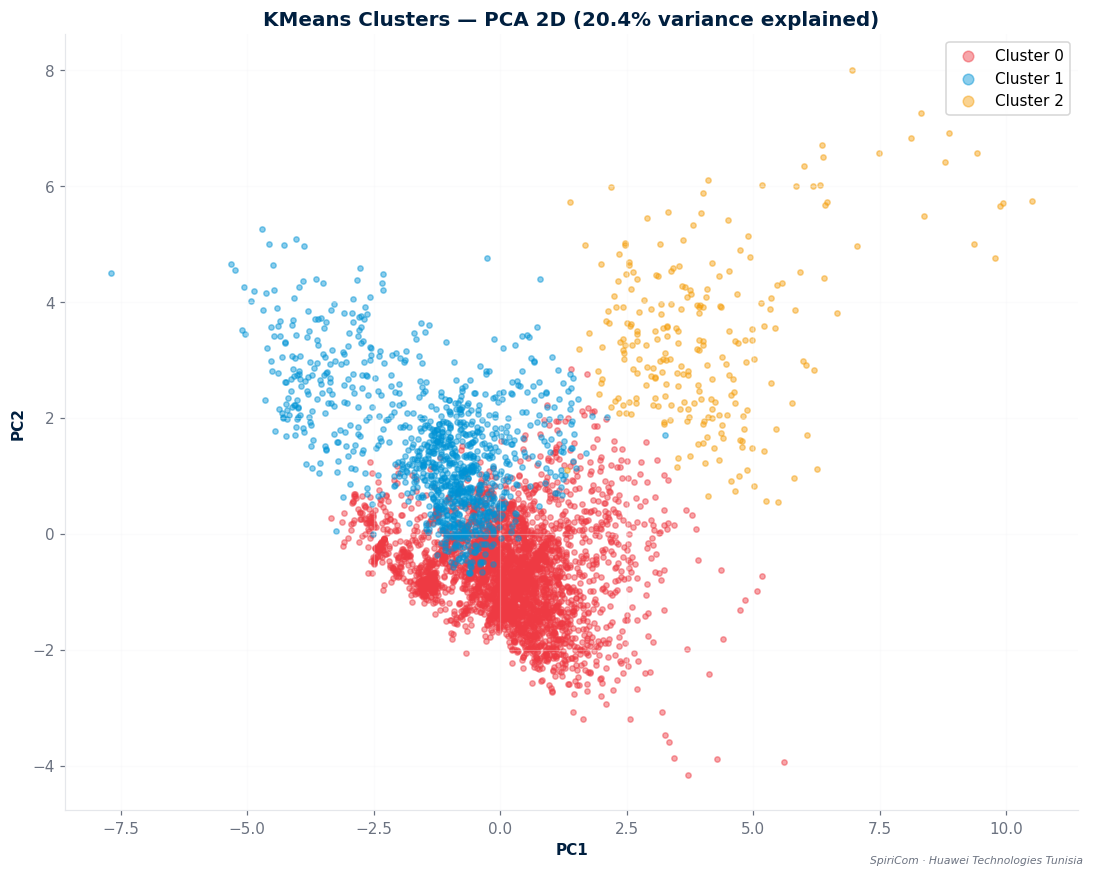

In [5]:
# ── 4.1  Fit final KMeans with OPTIMAL_K ─────────────────────────────
print(f'Fitting KMeans (k={OPTIMAL_K})...')
km_final = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42)
km_labels = km_final.fit_predict(X_scaled)

# ── 4.2  Assign cluster labels + PCA coords to feat_df ────────────────
result_df = feat_df.copy()
result_df['kmeans_cluster'] = km_labels
result_df['pca_x']          = X_2d[:, 0]
result_df['pca_y']          = X_2d[:, 1]

# Province name
if prov_col and province_map:
    result_df['region'] = result_df[prov_col].apply(
        lambda x: province_map.get(int(x), f'Province {x}')
    )

# ── 4.3  Cluster profiles ─────────────────────────────────────────────
print(f'\nCluster profiles (mean KPI values):')
print(f'{"Cluster":<10} {"N":>6}  {"Pct":>6}  Top features...')
for cid in sorted(result_df['kmeans_cluster'].unique()):
    grp  = result_df[result_df['kmeans_cluster'] == cid]
    pct  = round(len(grp) / len(result_df) * 100, 1)
    # Top 3 distinguishing features
    means_all = result_df[FEAT_COLS].mean()
    means_cls = grp[FEAT_COLS].mean()
    deviation = ((means_cls - means_all) / (means_all.abs() + 1e-8)).abs().nlargest(3)
    top_feat  = ', '.join([f'{f}={means_cls[f]:.3f}' for f in deviation.index])
    print(f'  Cluster {cid:<3} {len(grp):>6,}  {pct:>5.1f}%  {top_feat}')

# ── 4.4  PCA scatter ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
for cid in sorted(result_df['kmeans_cluster'].unique()):
    grp = result_df[result_df['kmeans_cluster'] == cid]
    ax.scatter(grp['pca_x'], grp['pca_y'],
               c=PALETTE[cid % len(PALETTE)], alpha=0.45, s=12, label=f'Cluster {cid}')
ax.set_title(f'KMeans Clusters — PCA 2D ({var_2d}% variance explained)',
             fontsize=13, fontweight='bold', color=HW['navy'])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=10, markerscale=2)
ax.grid(alpha=0.3)
wm(fig); plt.tight_layout()
save_fig('fig03b_C_pca_scatter')
plt.show()

---
## §5 — DBSCAN Outlier Detection

Running DBSCAN on PCA 2D...
  DBSCAN clusters : 2
  Noise points    : 62 (1.3%)
  Saved: data\outputs\figures\fig03b_D_dbscan.png


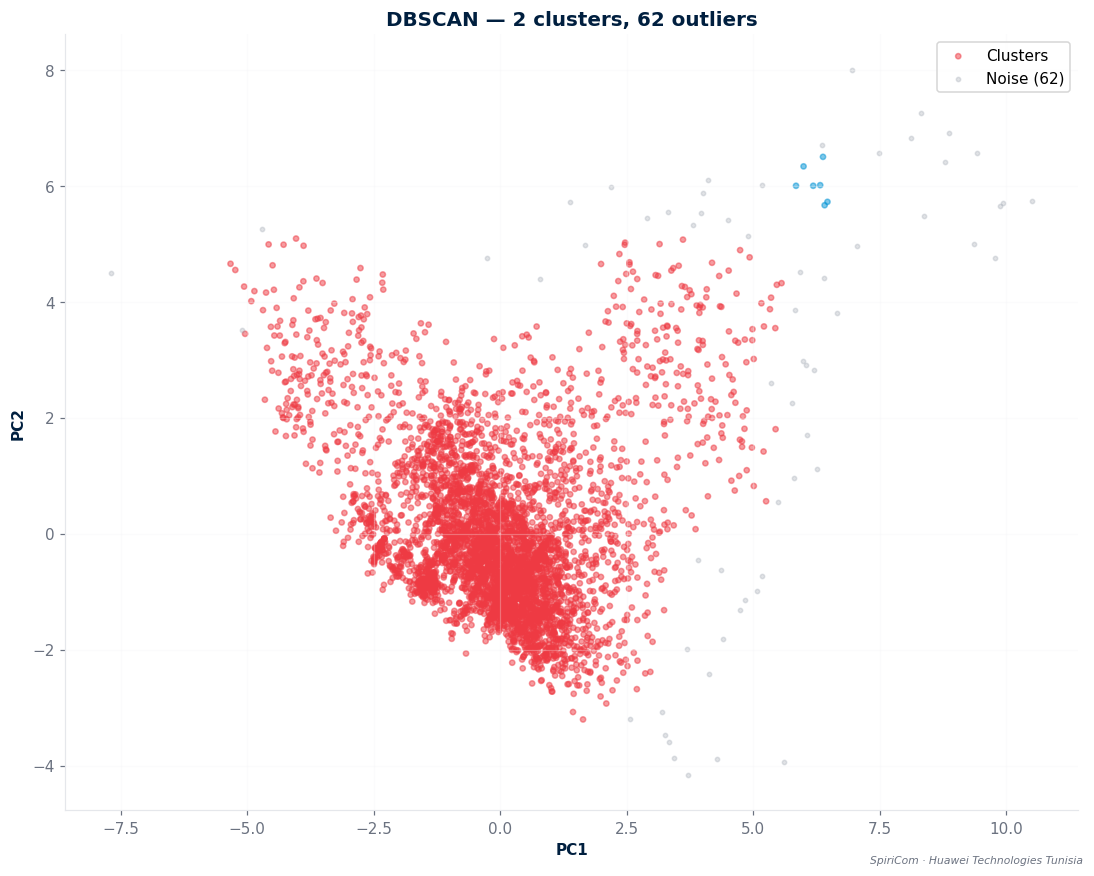

In [6]:
# ── 5.1  DBSCAN on 2D PCA ────────────────────────────────────────────
# Using PCA-reduced data makes DBSCAN faster and eps tuning easier
print('Running DBSCAN on PCA 2D...')
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_2d)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = int((db_labels == -1).sum())
print(f'  DBSCAN clusters : {n_clusters_db}')
print(f'  Noise points    : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

# ── 5.2  Tune eps if no clusters found ───────────────────────────────
if n_clusters_db == 0:
    print('  ⚠ No clusters found — trying eps=1.0')
    db = DBSCAN(eps=1.0, min_samples=5)
    db_labels = db.fit_predict(X_2d)
    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise       = int((db_labels == -1).sum())
    print(f'  eps=1.0: clusters={n_clusters_db}, noise={n_noise}')

result_df['dbscan_cluster'] = db_labels

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
noise_mask = db_labels == -1
ax.scatter(X_2d[~noise_mask, 0], X_2d[~noise_mask, 1],
           c=[PALETTE[l % len(PALETTE)] for l in db_labels[~noise_mask]],
           alpha=0.5, s=12, label='Clusters')
ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
           c='#9CA3AF', alpha=0.3, s=8, label=f'Noise ({n_noise})')
ax.set_title(f'DBSCAN — {n_clusters_db} clusters, {n_noise} outliers',
             fontsize=13, fontweight='bold', color=HW['navy'])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
wm(fig); plt.tight_layout()
save_fig('fig03b_D_dbscan')
plt.show()

---
## §6 — Save Artifacts

In [7]:
# ── 6.1  Save kmeans_users.parquet ───────────────────────────────────
# Save the FULL result_df (with kmeans_cluster, pca_x, pca_y, region)
# The API reads this file for /api/analytics/segments/profiles
km_path = CLUST_DIR / 'kmeans_users.parquet'
result_df.to_parquet(km_path, index=False)
print(f'✅ kmeans_users.parquet saved: {km_path}')
print(f'   Rows: {len(result_df):,}  Cols: {list(result_df.columns[:8])}...')

# ── 6.2  Save DBSCAN parquet ─────────────────────────────────────────
db_path = CLUST_DIR / 'dbscan_users.parquet'
result_df[['dbscan_cluster']].to_parquet(db_path, index=False)
print(f'✅ dbscan_users.parquet saved: {db_path}')

# ── 6.3  Save scaler ─────────────────────────────────────────────────
joblib.dump(scaler,   CLUST_DIR / 'scaler.pkl')
joblib.dump(km_final, CLUST_DIR / 'kmeans.pkl')
print(f'✅ scaler.pkl + kmeans.pkl saved')

# ── 6.4  Summary ─────────────────────────────────────────────────────
figs = sorted(FIG_DIR.glob('fig03b_*.png'))
sil_final = round(float(silhouette_score(
    X_scaled, km_labels,
    sample_size=min(2000, len(X_scaled)), random_state=42)), 3)
dbi_final = round(float(davies_bouldin_score(X_scaled, km_labels)), 3)

print('\n' + '═'*60)
print('NB03b — SUBSCRIBER CLUSTERING COMPLETE (Dataset 2)')
print('═'*60)
print(f'  Subscribers     : {len(result_df):,}')
print(f'  KPI features    : {len(FEAT_COLS)}')
print(f'  PCA variance 2D : {var_2d}%')
print(f'  Optimal k       : {OPTIMAL_K}')
print(f'  Silhouette      : {sil_final}  (higher = better, max 1.0)')
print(f'  Davies-Bouldin  : {dbi_final}  (lower  = better, min 0.0)')
print(f'  DBSCAN clusters : {n_clusters_db}')
print(f'  DBSCAN noise    : {n_noise} ({n_noise/len(result_df)*100:.1f}%)')
print()
print('  Cluster sizes:')
for cid in sorted(result_df['kmeans_cluster'].unique()):
    n   = (result_df['kmeans_cluster'] == cid).sum()
    pct = round(n / len(result_df) * 100, 1)
    bar = '█' * int(pct / 2)
    print(f'    Cluster {cid}: {n:,}  ({pct}%)  {bar}')
print()
print('  Artifacts saved:')
print(f'    {km_path}      ← feeds /api/analytics/segments/profiles')
print(f'    {db_path}')
print(f'    {CLUST_DIR}/pca.pkl  scaler.pkl  kmeans.pkl')
print()
print(f'  Figures ({len(figs)}):')
for fp in figs:
    print(f'    {fp.name}')
print()
print('  Dashboard: UserSegments → Dataset 2 tab  ✅')

✅ kmeans_users.parquet saved: models\clustering\kmeans_users.parquet
   Rows: 4,896  Cols: ['msisdn', 'churn', 'avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g']...
✅ dbscan_users.parquet saved: models\clustering\dbscan_users.parquet
✅ scaler.pkl + kmeans.pkl saved

════════════════════════════════════════════════════════════
NB03b — SUBSCRIBER CLUSTERING COMPLETE (Dataset 2)
════════════════════════════════════════════════════════════
  Subscribers     : 4,896
  KPI features    : 24
  PCA variance 2D : 20.4%
  Optimal k       : 3
  Silhouette      : 0.16  (higher = better, max 1.0)
  Davies-Bouldin  : 2.312  (lower  = better, min 0.0)
  DBSCAN clusters : 2
  DBSCAN noise    : 62 (1.3%)

  Cluster sizes:
    Cluster 0: 3,586  (73.2%)  ████████████████████████████████████
    Cluster 1: 1,066  (21.8%)  ██████████
    Cluster 2: 244  (5.0%)  ██

  Artifacts saved:
    models\clustering\kmeans_users.parquet      ← feeds /api/analytics/

---
## Summary

### Pipeline
```
churn_features.parquet (4,896 subscribers, 24 KPI features)
         ↓
  StandardScaler → PCA(2D)     → pca_x, pca_y per subscriber
  Elbow + Silhouette           → optimal k
  KMeans(k=optimal)            → kmeans_cluster per subscriber
  DBSCAN(eps=0.5)              → dbscan_cluster (-1 = outlier)
         ↓
  models/clustering/
    kmeans_users.parquet   ← API reads this
    dbscan_users.parquet
    pca.pkl  scaler.pkl  kmeans.pkl
```

### Dashboard integration
```
GET /api/analytics/segments/profiles
  → reads kmeans_users.parquet
  → returns cluster profiles with PCA scatter

GET /api/analytics/segments/region-distribution
  → cross-tabs kmeans_cluster × region

UserSegments.jsx — Dataset 2 tab
  → PCA scatter, radar, KPI profiles, distribution chart
```

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*